# First-diff logistic: grid search tuning

Grid search over `(window, low_thresh, high_thresh)`, visualise the AUROC surface, fit the final model, and save it.

In [15]:
import sys
sys.path.append("../../..")

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score, log_loss, brier_score_loss

import models.first_diff_logistic as fdl

with open("../../../data_processing/splits/train.pkl", "rb") as f:
    train_homes = pickle.load(f)
with open("../../../data_processing/splits/test.pkl", "rb") as f:
    test_homes = pickle.load(f)

print(f"Train: {len(train_homes)} homes ({sum(v[0] for v in train_homes.values())} EV)")
print(f"Test:  {len(test_homes)} homes ({sum(v[0] for v in test_homes.values())} EV)")

Train: 54 homes (9 EV)
Test:  18 homes (3 EV)


## Grid search — log full results

In [16]:
loads = [df["load"].to_numpy() for _, (_, _, df) in train_homes.items()]
y     = np.array([int(has_car) for _, (has_car, _, _) in train_homes.items()])

windows      = [2, 4, 6]
low_grid     = np.arange(0.4, 1.6, 0.4)
high_grid    = np.arange(1.2, 3.2, 0.4)
max_dur_grid = [16, 32, 48]

records = []
for w in windows:
    for lo in low_grid:
        for hi in high_grid:
            if hi <= lo:
                continue
            for md in max_dur_grid:
                X = [[fdl.transitions_per_day(load, w, lo, hi, md)] for load in loads]
                model = LogisticRegression(class_weight="balanced", max_iter=1000).fit(X, y)
                score = average_precision_score(y, model.predict_proba(X)[:, 1])
                records.append({"window": w, "low": round(lo, 2), "high": round(hi, 2), "max_duration": md, "avg_precision": score})

grid_df = pd.DataFrame(records)
print(grid_df.sort_values("avg_precision", ascending=False).head(10))

     window  low  high  max_duration  avg_precision
132       6  1.2   1.6            16       0.545668
137       6  1.2   2.0            48       0.529394
134       6  1.2   1.6            48       0.527855
136       6  1.2   2.0            32       0.517778
135       6  1.2   2.0            16       0.517284
133       6  1.2   1.6            32       0.511189
120       6  0.8   1.6            16       0.498812
123       6  0.8   2.0            16       0.493874
139       6  1.2   2.4            32       0.490505
138       6  1.2   2.4            16       0.490505


## Visualise — AUROC heatmap per window size

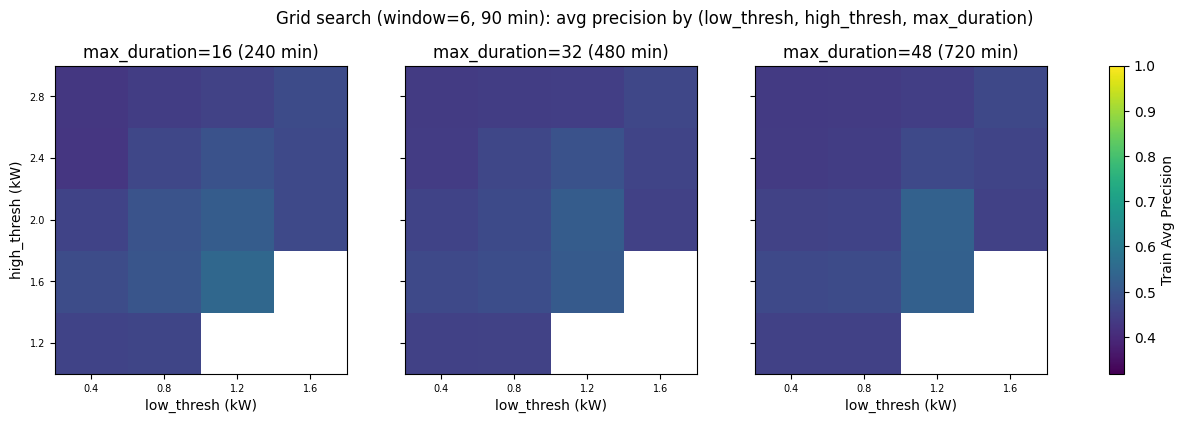

In [22]:
best_window = grid_df.loc[grid_df["avg_precision"].idxmax(), "window"]
sub = grid_df[grid_df["window"] == best_window]

fig, axes = plt.subplots(1, len(max_dur_grid), figsize=(16, 4), sharey=True)
for ax, md in zip(axes, max_dur_grid):
    pivot = sub[sub["max_duration"] == md].pivot(index="high", columns="low", values="avg_precision")
    im = ax.imshow(pivot.values, aspect="auto", origin="lower",
                   vmin=grid_df["avg_precision"].min(), vmax=1.0, cmap="viridis")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns.round(1), fontsize=7)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index.round(1), fontsize=7)
    ax.set_title(f"max_duration={md} ({md*15} min)")
    ax.set_xlabel("low_thresh (kW)")
    if ax is axes[0]:
        ax.set_ylabel("high_thresh (kW)")

fig.colorbar(im, ax=axes, label="Train Avg Precision")
plt.suptitle(f"Grid search (window={best_window}, {best_window*15} min): avg precision by (low_thresh, high_thresh, max_duration)", y=1.02)
plt.show()

## Fit final model and evaluate on test homes

In [18]:
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss, average_precision_score

model, window, low, high, max_dur = fdl.tune(train_homes)
results, charge_states = fdl.predict(model, test_homes, window, low, high, max_dur)

y_test, p_test = results["has_ev"].to_numpy(), results["p_hat"].to_numpy()
print(f"Avg Precision: {average_precision_score(y_test, p_test):.4f}")
print(f"AUROC        : {roc_auc_score(y_test, p_test):.4f}")
print(f"Log-loss     : {log_loss(y_test, p_test):.4f}")
print(f"Brier        : {brier_score_loss(y_test, p_test):.4f}")
results.sort_values("p_hat", ascending=False)

Best: window=6 (90 min), low=1.2, high=1.6, max_duration=16 (240 min)  (train avg precision=0.5457)
Avg Precision: 1.0000
AUROC        : 1.0000
Log-loss     : 0.2414
Brier        : 0.0509


,dataid,has_ev,transitions_per_day,p_hat
1,1222,1,3.337,0.937
2,1642,1,2.266,0.783
0,5679,1,1.978,0.712
8,7800,0,1.133,0.446
16,8565,0,0.686,0.308
6,1417,0,0.587,0.281
13,5587,0,0.511,0.261
4,8061,0,0.390,0.231
12,7114,0,0.386,0.230
15,2318,0,0.217,0.193


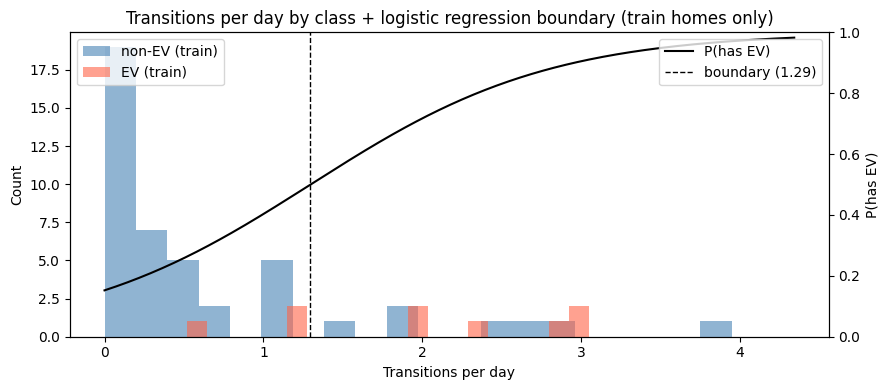

In [19]:
train_rates  = np.array([fdl.transitions_per_day(df["load"].to_numpy(), window, low, high, max_dur)
                          for _, (_, _, df) in train_homes.items()])
train_labels = np.array([int(has_car) for _, (has_car, _, _) in train_homes.items()])

x_range = np.linspace(0, train_rates.max() * 1.1, 300)
p_curve  = model.predict_proba(x_range.reshape(-1, 1))[:, 1]
boundary = x_range[np.argmin(np.abs(p_curve - 0.5))]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(train_rates[train_labels == 0], bins=20, alpha=0.6, label="non-EV (train)", color="steelblue")
ax.hist(train_rates[train_labels == 1], bins=20, alpha=0.6, label="EV (train)", color="tomato")

ax2 = ax.twinx()
ax2.plot(x_range, p_curve, color="black", linewidth=1.5, label="P(has EV)")
ax2.axvline(boundary, color="black", linestyle="--", linewidth=1, label=f"boundary ({boundary:.2f})")
ax2.set_ylim(0, 1)
ax2.set_ylabel("P(has EV)")

ax.set_xlabel("Transitions per day")
ax.set_ylabel("Count")
ax.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.title("Transitions per day by class + logistic regression boundary (train homes only)")
plt.tight_layout()
plt.show()

## Visualise predicted vs actual charge state

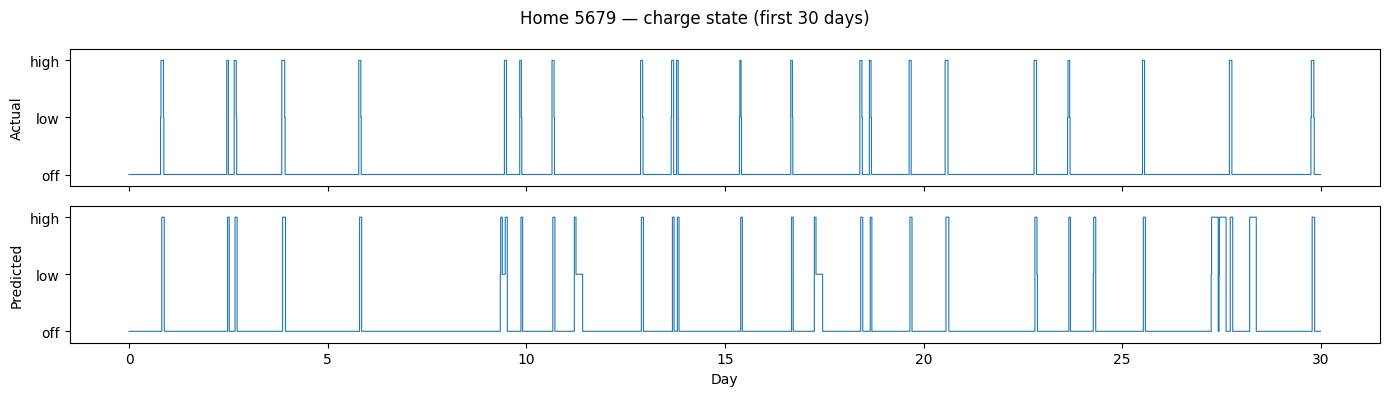

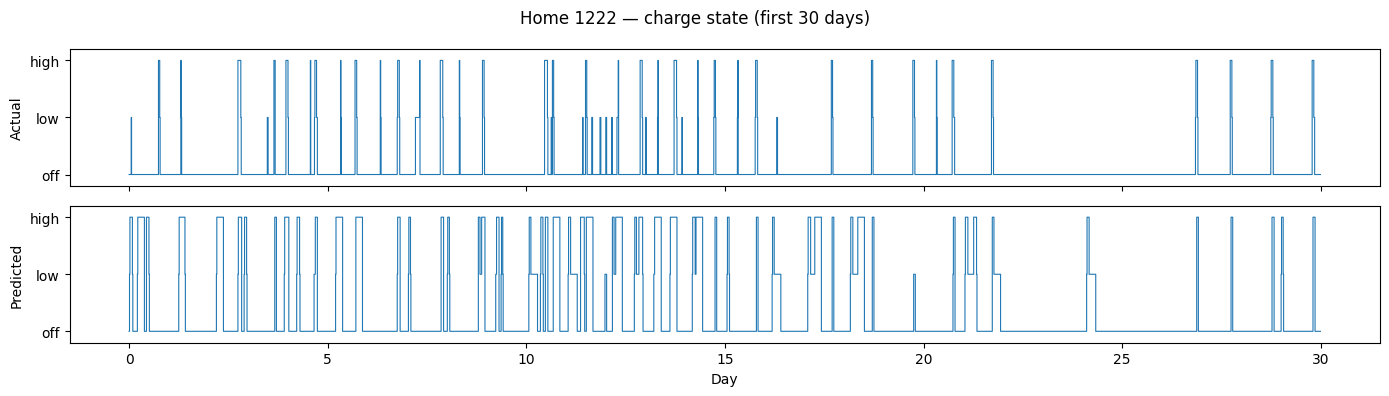

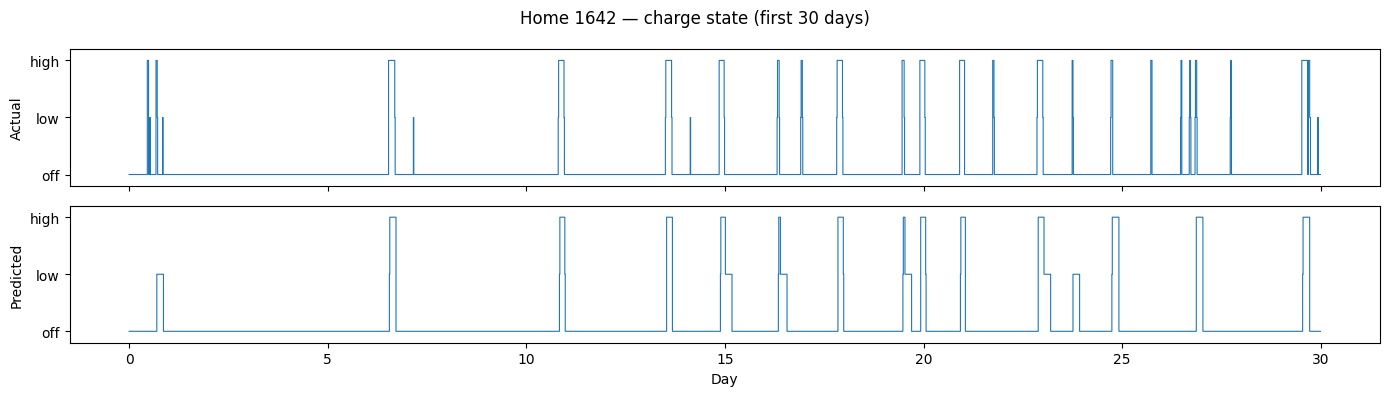

In [20]:
def plot_charge_states(dataid, charge_states, test_homes, n_days=30):
    """Plot predicted vs actual charge state for a test home over n_days."""
    _, _, df = test_homes[dataid]
    actual = df["charge_state"].to_numpy()
    predicted = charge_states[dataid]

    n_steps = n_days * 96
    t = np.arange(n_steps) / 96  # time in days

    fig, axes = plt.subplots(2, 1, figsize=(14, 4), sharex=True)
    for ax, signal, label in zip(axes, [actual, predicted], ["Actual", "Predicted"]):
        ax.step(t, signal[:n_steps], where="post", linewidth=0.8)
        ax.set_yticks([0, 1, 2])
        ax.set_yticklabels(["off", "low", "high"])
        ax.set_ylabel(label)
        ax.set_ylim(-0.2, 2.2)

    axes[-1].set_xlabel("Day")
    fig.suptitle(f"Home {dataid} — charge state (first {n_days} days)")
    plt.tight_layout()
    plt.show()


# Plot all EV homes in the test set
ev_test_ids = [d for d, (has_car, _, _) in test_homes.items() if has_car]
for dataid in ev_test_ids:
    plot_charge_states(dataid, charge_states, test_homes)

## Save model

In [21]:
fdl.save(model, window, low, high, max_dur, "../../../models/first_diff_logistic.pkl")
print("Saved.")

Saved.
